In [4]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("CyclotronKW12.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks, argrelmax
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from Cyc_functions import lin_func, evaluator_scipy
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
CyclotronKW12.ipynb started: Sun, 29 Mar 2026 14:55:20
INFO: SETUP COMPLETE (0.00 ms)
---------------------------------------


## Loading Measurement Data

In [5]:
df = pd.read_csv('./2026_KW12/KW12_measurement.csv', header=0, delimiter=',')
print(df)

     HF Frequency  HF Preselect /Skt  HF Voltage / mV  Cup3 Current / muA  \
0         22.9577              751.0             37.6               22.50   
1         22.9577              950.0             48.0               24.00   
2         22.9577              900.0             45.4               24.00   
3         22.9577              875.0             44.1               24.00   
4         22.9577              850.0             42.8               24.00   
..            ...                ...              ...                 ...   
156       22.9617              875.0             44.3               24.25   
157       22.9617              900.0             45.5               24.25   
158       22.9617              855.0             43.2               24.50   
159       22.9592              735.0             36.8               24.00   
160       22.9592              735.0             36.8               24.00   

     ST1 Current / nA  TransEff  
0               700.0    0.0311  
1      

### HF Preselect Skt vs. Voltage

In [30]:
init_values = [0.1,1]
x_data = df.iloc[:,2].tolist()
y_data = df.iloc[:,1].tolist()
x_err = np.array([0.1]*len(x_data))
y_err = np.array([2.0]*len(x_data))

beta = evaluator_scipy(func=lin_func, beta0_list=init_values,
                           x=x_data, y=y_data,
                           xerr=x_err, yerr=y_err)

param_h = [beta['param'][0] + beta['errors'][0], beta['param'][1] + beta['errors'][1]]
param_l = [beta['param'][0] - beta['errors'][0], beta['param'][1] - beta['errors'][1]]

PARAMS: [19.17209043 27.72294079]
UNCERT: [0.02632669 1.05701354]


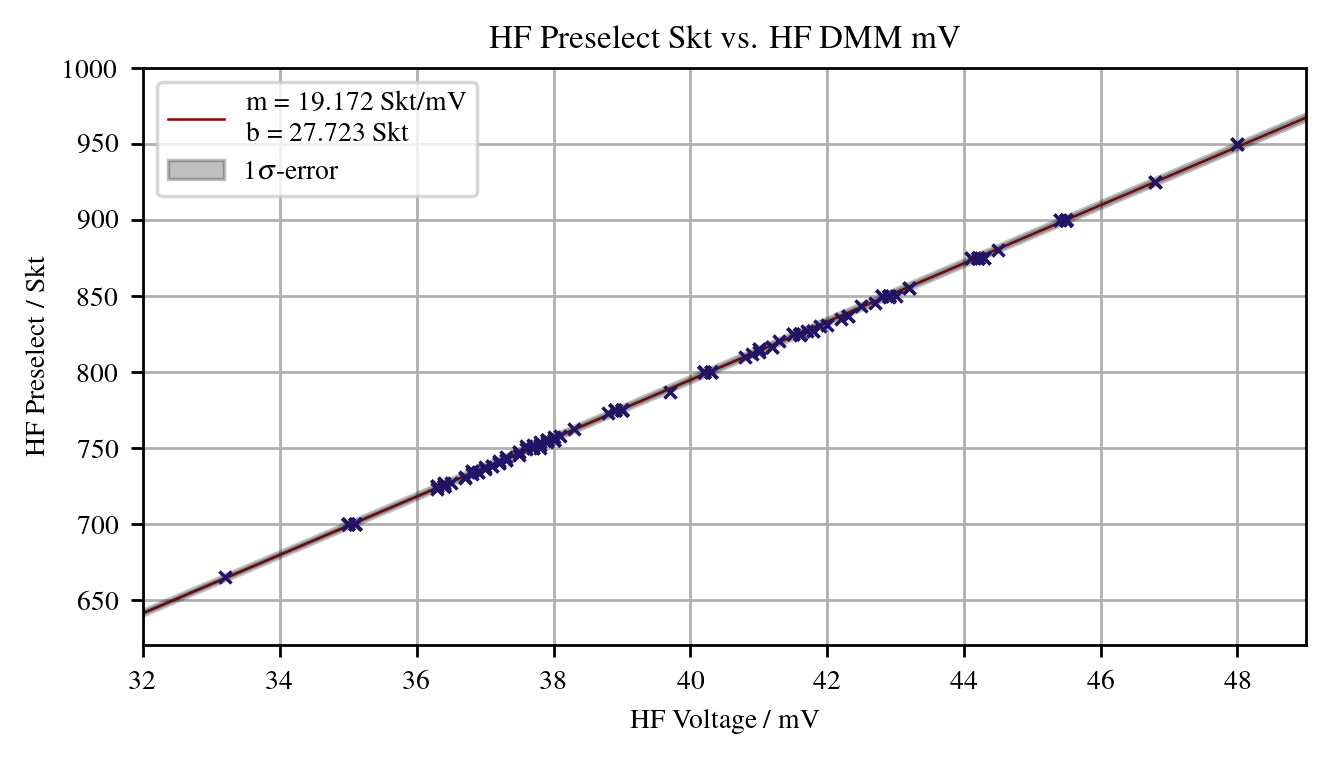

In [37]:
DPI = 250
x_lin = np.linspace(30,50,1000)
plt.figure(figsize=(6,3), dpi=DPI)
plt.scatter(df.iloc[:,2],df.iloc[:,1],s=12,marker='x',lw=1, c=color_schemes['c_dark'][0], zorder=3)
plt.plot(x_lin,lin_func(beta['param'],x_lin),lw=0.75, color=color_schemes['c_dark'][3], zorder=2, label=f'm = {round(beta['param'][0],3)} Skt/mV \n b = {round(beta['param'][1],3)} Skt')
plt.fill_between(x_lin,lin_func(param_l,x_lin),lin_func(param_h,x_lin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')

plt.xlim(32,49)
plt.ylim(620,1000)

plt.xlabel('HF Voltage / mV')
plt.ylabel('HF Preselect / Skt')
plt.grid()
plt.legend()
plt.title('HF Preselect Skt vs. HF DMM mV')

plt.show()